In [15]:
from brian2 import *
import matplotlib.pyplot as plt
import pandas as pd
import os, time

prefs.codegen.target = 'numpy'
file_path = "inspection_junk.csv"
# ============================================================
# CONFIGURATION
# ============================================================
PASS_LETTER = "A"
TRIALS_TO_RUN = [1]
START_SEED = 1
sweep_parameter = "gEEN"          
sweep_values = [0.165]

# Load or create dataset
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
else:
    df = pd.DataFrame()

# ============================================================
# MAIN SWEEP LOOP
# ============================================================

for value in sweep_values:
    print(f"\n\n==============================")
    print(f" RUNNING {sweep_parameter} = {value}")
    print(f"==============================\n")

    for trial in TRIALS_TO_RUN:
        print(f"\n=== TRIAL {trial} ===")

        # Reset Brian2
        start_scope()

        # Create seed label like A01, A02, ..., A10
        seed_label = f"{PASS_LETTER}{trial:02d}"

        # Numeric seed for RNG (1–10)
        numeric_seed = trial

        # Apply randomness
        np.random.seed(numeric_seed)
        seed(numeric_seed)
        import random
        random.seed(numeric_seed)

        # ============================================================
        # PARAMETER OVERRIDES
        # ============================================================

        # Default values
        coh = 15
        gEEN = 0.165 * nS / 1600 * 1600
        gEIN = 0.130 * nS / 1600 * 1600

        # Override the chosen parameter
        if sweep_parameter == "coh":
            coh = value

        elif sweep_parameter == "gEEN":
            gEEN = value * nS / 1600 * 1600

        elif sweep_parameter == "gEIN":
            gEIN = value * nS / 1600 * 1600

        elif sweep_parameter == "gIE":
            gIE = value * nS / 400 * 400

        # ============================================================
        # YOUR FULL MODEL (unchanged)
        # ============================================================

        # Stimulus and simulation parameters
        sigma = 4.0 * Hz
        mu0 = 40.0 * Hz
        mu1 = 40.0 * Hz
        stim_interval = 50.0 * ms
        stim_on = 1000 * ms
        stim_off = 3000 * ms
        runtime = 4000 * ms

        N_ext = 1000
        rate_ext_E = 2400 * Hz / N_ext
        rate_ext_I = 2400 * Hz / N_ext

        N = 2000
        f_inh = 0.2
        NE = int(N * (1 - f_inh))
        NI = int(N * f_inh)
        fE = 0.15
        subN = int(fE * NE)

        El = -70*mV
        Vt = -50*mV
        Vr = -55*mV
        CmE = 0.5*nF
        CmI = 0.2*nF
        gLeakE = 25*nS
        gLeakI = 20*nS
        refE = 2*ms
        refI = 1*ms

        V_E = 0*mV
        V_I = -70*mV
        tau_AMPA = 2*ms
        tau_NMDA_rise = 2*ms
        tau_NMDA_decay = 100*ms
        tau_GABA = 5*ms
        alpha = 0.5*kHz
        C = 1*mmole

        gextE = 2.1*nS
        gextI = 1.62*nS
        gEEA = 0.05*nS / NE * 1600
        gEIA = 0.04*nS / NE * 1600
        # gEEN already overridden above
        # gEIN already overridden above
        gIE  = 1.3   * nS / 400  * 400
        gII = 1.0*nS / NI * 400

        Jp = 1.7
        Jm = 1.0 - fE*(Jp-1)/(1-fE)

        eqsE = """
           label : integer (constant)
           dV/dt = (- gLeakE*(V-El) - I_AMPA - I_NMDA - I_GABA - I_AMPA_ext + I_input)/CmE : volt (unless refractory)
           I_AMPA = s_AMPA*(V-V_E) : amp
           ds_AMPA/dt = -s_AMPA/tau_AMPA : siemens
           I_NMDA = gEEN*s_NMDA_tot*(V-V_E)/(1+exp(-0.062*V/mvolt)*(C/mmole/3.57)) : amp
           s_NMDA_tot : 1
           I_GABA = s_GABA*(V-V_I) : amp
           ds_GABA/dt = -s_GABA/tau_GABA : siemens
           I_AMPA_ext = s_AMPA_ext*(V-V_E) : amp
           ds_AMPA_ext/dt = -s_AMPA_ext/tau_AMPA : siemens
           I_input : amp
           ds_NMDA/dt = -s_NMDA/tau_NMDA_decay + alpha*x*(1-s_NMDA) : 1
           dx/dt = -x/tau_NMDA_rise : 1
        """

        eqsI = """
           dV/dt = (- gLeakI*(V-El) - I_AMPA - I_NMDA - I_GABA - I_AMPA_ext)/CmI : volt (unless refractory)
           I_AMPA = s_AMPA*(V-V_E) : amp
           ds_AMPA/dt = -s_AMPA/tau_AMPA : siemens
           I_NMDA = gEIN*s_NMDA_tot*(V-V_E)/(1+exp(-0.062*V/mvolt)*(C/mmole/3.57)) : amp
           s_NMDA_tot : 1
           I_GABA = s_GABA*(V-V_I) : amp
           ds_GABA/dt = -s_GABA/tau_GABA : siemens
           I_AMPA_ext = s_AMPA_ext*(V-V_E) : amp
           ds_AMPA_ext/dt = -s_AMPA_ext/tau_AMPA : siemens
        """

        popE = NeuronGroup(NE, eqsE, threshold='V>Vt', reset='V=Vr', refractory=refE, method='euler')
        popI = NeuronGroup(NI, eqsI, threshold='V>Vt', reset='V=Vr', refractory=refI, method='euler')

        popE1 = popE[:subN]
        popE2 = popE[subN:2*subN]
        popE3 = popE[2*subN:]
        popE1.label = 0
        popE2.label = 1
        popE3.label = 2

        C_EE_AMPA = Synapses(popE, popE, 'w:siemens', on_pre='s_AMPA += w', delay=0.5*ms)
        C_EE_AMPA.connect()
        C_EE_AMPA.w[:] = gEEA
        C_EE_AMPA.w["label_pre==label_post and label_pre<2"] = gEEA*Jp
        C_EE_AMPA.w["label_pre!=label_post and label_post<2"] = gEEA*Jm

        C_EI_AMPA = Synapses(popE, popI, on_pre='s_AMPA += gEIA', delay=0.5*ms)
        C_EI_AMPA.connect()

        C_EE_NMDA = Synapses(popE, popE, on_pre='x_pre += 1', delay=0.5*ms)
        C_EE_NMDA.connect(j='i')

        NMDA_sum_group = NeuronGroup(3, 's:1')
        NMDA_sum = Synapses(popE, NMDA_sum_group, 's_post = s_NMDA_pre : 1 (summed)')
        NMDA_sum.connect(j='label_pre')

        NMDA_set_total_E = Synapses(NMDA_sum_group, popE,
            '''w:1
               s_NMDA_tot_post = w*s_pre : 1 (summed)''')
        NMDA_set_total_E.connect()
        NMDA_set_total_E.w = 1
        NMDA_set_total_E.w["i==label_post and label_post<2"] = Jp
        NMDA_set_total_E.w["i!=label_post and label_post<2"] = Jm

        NMDA_set_total_I = Synapses(NMDA_sum_group, popI,
            's_NMDA_tot_post = s_pre : 1 (summed)')
        NMDA_set_total_I.connect()

        C_IE = Synapses(popI, popE, on_pre='s_GABA += gIE', delay=0.5*ms)
        C_IE.connect()

        C_II = Synapses(popI, popI, on_pre='s_GABA += gII', delay=0.5*ms)
        C_II.connect()

        extinputE = PoissonInput(popE, 's_AMPA_ext', N_ext, rate_ext_E, gextE)
        extinputI = PoissonInput(popI, 's_AMPA_ext', N_ext, rate_ext_I, gextI)

        stiminputE1 = PoissonGroup(subN, rates=0*Hz)
        stiminputE2 = PoissonGroup(subN, rates=0*Hz)
        stiminputE1.run_regularly("rates = int(t>stim_on and t<stim_off)*(mu0 + coh/100*mu1 + sigma*randn())", dt=stim_interval)
        stiminputE2.run_regularly("rates = int(t>stim_on and t<stim_off)*(mu0 - coh/100*mu1 + sigma*randn())", dt=stim_interval)

        C_stimE1 = Synapses(stiminputE1, popE1, on_pre='s_AMPA_ext += gextE')
        C_stimE1.connect(j='i')
        C_stimE2 = Synapses(stiminputE2, popE2, on_pre='s_AMPA_ext += gextE')
        C_stimE2.connect(j='i')

        popE.s_NMDA_tot = tau_NMDA_decay * 10*Hz * 0.2
        popI.s_NMDA_tot = tau_NMDA_decay * 10*Hz * 0.2
        popE.V = Vt - 2*mV
        popI.V = Vt - 2*mV

        SME1 = SpikeMonitor(popE1)
        SME2 = SpikeMonitor(popE2)
        R1 = PopulationRateMonitor(popE1)
        R2 = PopulationRateMonitor(popE2)

        # ============================================================
        # RUN TRIAL
        # ============================================================
        run(runtime, report='stdout')

        # ============================================================
        # METRICS
        # ============================================================

        rate1 = R1.smooth_rate(window='gaussian', width=50*ms)
        rate2 = R2.smooth_rate(window='gaussian', width=50*ms)

        # Detect threshold crossings
        threshold = 10*Hz
        cross1 = np.where(rate1 > threshold)[0]
        cross2 = np.where(rate2 > threshold)[0]

        # Decision times
        dt1 = R1.t[cross1[0]]/ms if len(cross1) > 0 else None
        dt2 = R2.t[cross2[0]]/ms if len(cross2) > 0 else None

        # Determine if a decision was made
        made_decision = (len(cross1) > 0) or (len(cross2) > 0)

        # Determine winner (1 or 2) if decision exists
        if made_decision:
            winner = 1 if np.max(rate1) > np.max(rate2) else 2
        else:
            winner = 0   # no decision

        # ============================================================
        # ACCURACY CODING FOR HEATMAP GRADIENT
        # 0 = no decision (worst)
        # 1 = wrong       (middle)
        # 2 = correct     (best)
        # ============================================================

        if winner == 0:
            acc_code = 0
        elif winner == 1:
            acc_code = 2
        else:
            acc_code = 1

        # Decision time (None for no decision)
        decision_time = dt1 if winner == 1 else dt2

        # Peak firing rates
        peak1 = np.max(rate1)/Hz
        peak2 = np.max(rate2)/Hz
        # ============================================================
        # SAVE ROW
        # ============================================================
        
        noise_E = float(rate_ext_E / Hz)
        noise_I = float(rate_ext_I / Hz)

        FILE = "inspection"
        
        new_row = {
            "coh": float(coh),
            "gEIN": float(gEIN / nS),
            "gEEN": float(gEEN / nS),
            "gIE":  float(gIE  / nS),
            "acc": int(acc_code),
            "dt1": float(dt1) if dt1 is not None else None,
            "dt2": float(dt2) if dt2 is not None else None,
            "dt":  float(decision_time) if decision_time is not None else None,
            "peak1": float(peak1),
            "peak2": float(peak2),
            "noise_E": noise_E,
            "noise_I": noise_I,
            "seed": seed_label
        }


        
        df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

        # ============================================================
        # SAFE SAVE
        # ============================================================
        saved = False
        while not saved:
            try:
                df.to_csv(file_path, index=False)
                saved = True
            except PermissionError:
                print("Excel is open — close it so I can save.")
                time.sleep(2)

print("\n=== ALL SWEEP TRIALS COMPLETE ===")




 RUNNING gEEN = 0.165


=== TRIAL 1 ===
Starting simulation at t=0. s for a duration of 4. s
0.3787 s (9%) simulated in 10s, estimated 1m 36s remaining.
0.7786 s (19%) simulated in 20s, estimated 1m 23s remaining.
1.1099 s (27%) simulated in 30s, estimated 1m 18s remaining.
1.3763 s (34%) simulated in 40s, estimated 1m 16s remaining.
1.8069 s (45%) simulated in 50s, estimated 1m 1s remaining.
2.3581 s (58%) simulated in 1m 0s, estimated 42s remaining.
2.9321 s (73%) simulated in 1m 10s, estimated 25s remaining.
3.5324 s (88%) simulated in 1m 20s, estimated 11s remaining.
4. s (100%) simulated in 1m 27s

=== ALL SWEEP TRIALS COMPLETE ===


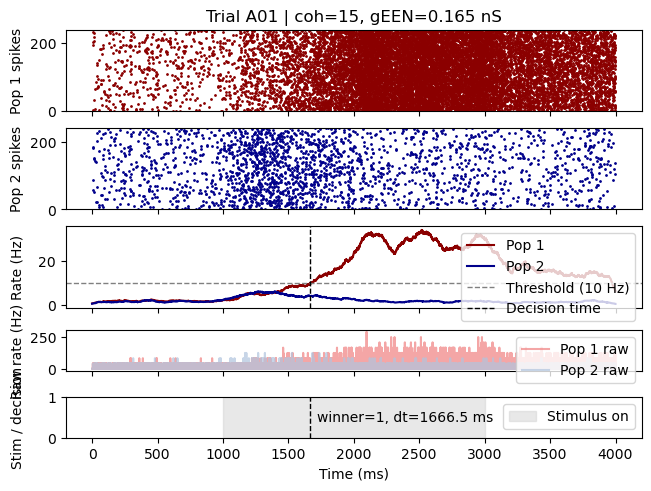

In [16]:
# ============================================================
# PANELLED ANALYSIS FIGURE
     # ============================================================

fig, axs = plt.subplots(
    5, 1,
    sharex=True,
    layout='constrained',
    gridspec_kw={'height_ratios': [2, 2, 2, 1, 1]}
)

# 1) Spike raster – population 1
axs[0].plot(SME1.t/ms, SME1.i, '.', markersize=2, color='darkred')
axs[0].set(
    ylabel='Pop 1 spikes',
    ylim=(0, subN)
)
axs[0].set_title(f"Trial {seed_label} | coh={coh}, gEEN={float(gEEN/nS):.3f} nS")

# 2) Spike raster – population 2
axs[1].plot(SME2.t/ms, SME2.i, '.', markersize=2, color='darkblue')
axs[1].set(
    ylabel='Pop 2 spikes',
    ylim=(0, subN)
)
        
# 3) Firing rates (smoothed)
rate1_flat = R1.smooth_rate(window='flat', width=100*ms)
rate2_flat = R2.smooth_rate(window='flat', width=100*ms)

axs[2].plot(R1.t/ms, rate1_flat/Hz, color='darkred', label='Pop 1')
axs[2].plot(R2.t/ms, rate2_flat/Hz, color='darkblue', label='Pop 2')
axs[2].axhline(10, color='gray', linestyle='--', linewidth=1, label='Threshold (10 Hz)')
if decision_time is not None:
    axs[2].axvline(decision_time, color='black', linestyle='--', linewidth=1, label='Decision time')
axs[2].set(ylabel='Rate (Hz)')
axs[2].legend(loc='upper right')

# 4) Raw (unsmoothed) rate monitor
axs[3].plot(R1.t/ms, R1.rate/Hz, color='lightcoral', alpha=0.7, label='Pop 1 raw')
axs[3].plot(R2.t/ms, R2.rate/Hz, color='lightsteelblue', alpha=0.7, label='Pop 2 raw')
axs[3].set(ylabel='Raw rate (Hz)')
axs[3].legend(loc='upper right')

# 5) Stimulus window + decision summary
axs[4].axvspan(stim_on/ms, stim_off/ms, color='lightgray', alpha=0.5, label='Stimulus on')
axs[4].set(
    xlabel='Time (ms)',
    ylabel='Stim / decision'
)
if decision_time is not None:
    axs[4].axvline(decision_time, color='black', linestyle='--', linewidth=1)
    axs[4].text(
        decision_time + 50, 0.5,
        f"winner={winner}, dt={decision_time:.1f} ms",
        va='center'
    )
axs[4].set_ylim(0, 1)
axs[4].legend(loc='upper right')

fig.align_ylabels(axs)
plt.show()


In [17]:
print("\n================ RUN METRICS ================")
print(f"Seed: {seed_label}")
print(f"Coherence: {coh}")
print(f"Decision made: {made_decision}")
print(f"Winner: {winner}")
print(f"Decision time: {decision_time} ms")
print(f"Peak firing rate pop1: {peak1:.2f} Hz")
print(f"Peak firing rate pop2: {peak2:.2f} Hz")
print(f"Accuracy code: {acc_code}")
print("=============================================\n")



================ RUN METRICS ================
Seed: A01
Coherence: 15
Decision made: True
Winner: 1
Decision time: 1666.5 ms
Peak firing rate pop1: 32.87 Hz
Peak firing rate pop2: 5.85 Hz
Accuracy code: 2



In [18]:
import pandas as pd

def match_report(seed, coh, gEEN, gEIN,
                 main_path="clean_database.csv",
                 insp_path="inspection_junk.csv"):
    # Load both datasets
    main_df = pd.read_csv(main_path)
    insp_df = pd.read_csv(insp_path)

    # Filter rows matching the full trial identity
    main_row = main_df[
        (main_df["seed"] == seed) &
        (main_df["coh"] == coh) &
        (main_df["gEEN"] == gEEN) &
        (main_df["gEIN"] == gEIN)
    ]

    insp_row = insp_df[
        (insp_df["seed"] == seed) &
        (insp_df["coh"] == coh) &
        (insp_df["gEEN"] == gEEN) &
        (insp_df["gEIN"] == gEIN)
    ]

    # Check if both exist
    if main_row.empty:
        print("❌ No matching trial found in MAIN dataset")
        return
    if insp_row.empty:
        print("❌ No matching trial found in INSPECTION dataset")
        return

    main_row = main_row.iloc[0]
    insp_row = insp_row.iloc[0]

    print(f"\n🔍 MATCH REPORT for trial:")
    print(f"seed={seed}, coh={coh}, gEEN={gEEN}, gEIN={gEIN}\n")

    # Fields to compare
    fields = ["dt1", "dt2", "dt", "peak1", "peak2", "acc"]

    all_match = True

    for field in fields:
        m = main_row[field]
        i = insp_row[field]

        if m == i:
            print(f"✔ {field}: MATCH")
        else:
            print(f"⚠ {field}: MISMATCH (main={m}, inspection={i})")
            all_match = False

    if all_match:
        print("\n🎉 RESULT: PERFECT MATCH — inspection file reproduced the trial exactly!")
    else:
        print("\n⚠ RESULT: PARTIAL MISMATCH — inspection file did NOT reproduce the trial exactly.")


match_report("A01, 15, 0.165, 0.130")


🔍 MATCH REPORT for trial:
seed=A01, coh=15, gEEN=0.165, gEIN=0.13

⚠ dt1: MISMATCH (main=1597.6, inspection=1704.6)
⚠ dt2: MISMATCH (main=nan, inspection=nan)
⚠ peak1: MISMATCH (main=33.80248976709387, inspection=33.02474817603669)
⚠ peak2: MISMATCH (main=5.9912437567857, inspection=5.107634706356806)


KeyError: 'winner'